# Car Price analysis

##### Analysis carried out on this dataset in this notebook is:
1. 🚗 Exploratory Data Analysis (EDA)

- Distribution of prices — histogram/boxplot to spot skewness and outliers
- Year distribution — how old are most cars in the dataset?
- Mileage distribution — identify high-mileage vs low-mileage segments
- Condition breakdown — bar chart of condition categories (e.g., Excellent Good, Fair, Poor)


2. 💰 Price Analysis

- Price vs Mileage — scatter plot
- Price vs Year — do newer cars command higher prices? (scatter/line)
- Price vs Condition — boxplot per condition category
- Price by Make — which brands hold value best? (grouped bar or boxplot)
- Price by Make + Condition — heatmap of average prices


3. 📉 Depreciation & Value Retention

- Price vs Age (current year − Year) — depreciation curve
- Mileage vs Age — do older cars have proportionally more miles?


4. 🔗 Correlation Analysis

- Correlation matrix across Year, Mileage, Price
- Check if mileage or age is a stronger price predictor


5. 🏷️ Make & Model Analysis

- Most common Makes/Models — frequency counts
- Best value models — lowest price for a given condition/year bracket
- Mileage by Make — are certain brands driven more?


6. 📊 Condition Analysis

- Condition vs Mileage — do high-mileage cars cluster in lower conditions?
- Condition vs Year — are older cars in worse condition?
- Average price per condition — clear pricing tiers?

In [1]:
%matplotlib inline
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from scipy.stats import skew
from ydata_profiling import ProfileReport

In [2]:
cars = pd.read_csv(r"C:\Users\user\Desktop\Mine\docs\Car price analsis and prediction models\datasets\CarPricesPrediction.csv")
cars.head()

,CarID,Make,Model,Year,Mileage,Condition,Price
0,1,Ford,Silverado,2022,18107,Excellent,19094.75
1,2,Toyota,Silverado,2014,13578,Excellent,27321.10
2,3,Chevrolet,Civic,2016,46054,Good,23697.30
3,4,Ford,Civic,2022,34981,Excellent,18251.05
4,5,Chevrolet,Civic,2019,63565,Excellent,19821.85


In [3]:
#shape of our data set
print(f"The datasets has {cars.shape[0]} rows and {cars.shape[1]} columns!")

The datasets has 1000 rows and 7 columns!


In [4]:
print(f"columns: {cars.columns}")

columns: Index(['CarID', 'Make', 'Model', 'Year', 'Mileage', 'Condition', 'Price'], dtype='object')


### Data cleaning

In [5]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   CarID      1000 non-null   int64  
 1   Make       1000 non-null   object 
 2   Model      1000 non-null   object 
 3   Year       1000 non-null   int64  
 4   Mileage    1000 non-null   int64  
 5   Condition  1000 non-null   object 
 6   Price      1000 non-null   float64
dtypes: float64(1), int64(3), object(3)
memory usage: 54.8+ KB


In [6]:
#check for null values
cars.isna().sum()

CarID        0
Make         0
Model        0
Year         0
Mileage      0
Condition    0
Price        0
dtype: int64

In [7]:
# droping carID
cars = cars.drop(columns='CarID')

Data is clean and ready for analysis!

---

### Exploratory Data Analysis (EDA) and Data visualization

In [8]:
# EDA using ydata_profiling
profile = ProfileReport(cars, title= 'my report', explorative=True)
profile.to_file(r"C:\Users\user\Desktop\Mine\docs\Car price analsis and prediction models\reports\report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 6/6 [00:00<00:00, 38.80it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

- Distribution of prices

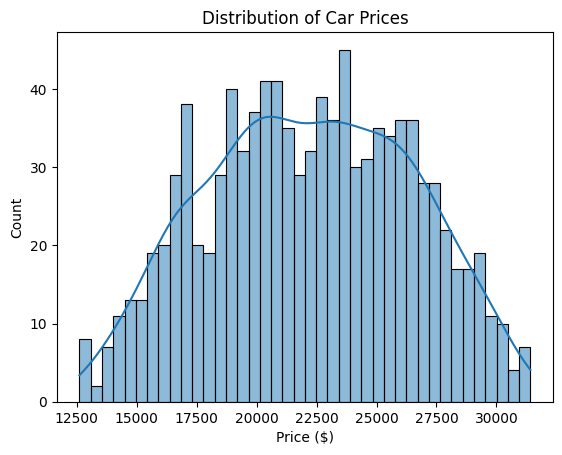

In [9]:
# histogram showing distribution of prices
sns.histplot(data=cars, x='Price', kde=True, bins=40)
plt.title('Distribution of Car Prices')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.savefig(r"C:\Users\user\Desktop\Mine\docs\Car price analsis and prediction models\visualizations\distribution of car prices.png")
plt.show()

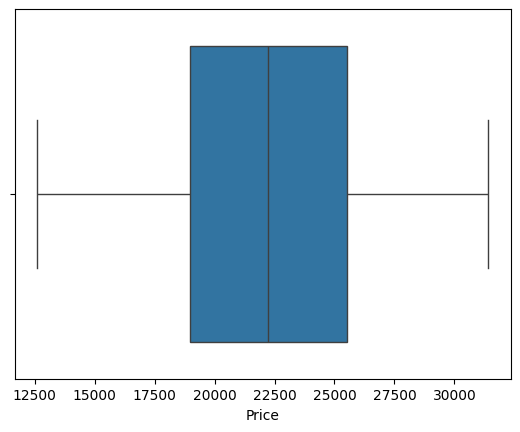

In [10]:
#boxplot showing distribution of prices
sns.boxplot(data=cars, x = 'Price')
plt.savefig(r"C:\Users\user\Desktop\Mine\docs\Car price analsis and prediction models\visualizations\distribution of car prices-boxplot.png")
plt.show()

In [11]:
print(f"Mean Price:   {cars['Price'].mean():,.2f}")
print(f"Median Price: {cars['Price'].median():,.2f}")
print(f"Skewness:     {cars['Price'].skew():.2f}")
print(f"Outliers:     {((cars['Price'] < cars['Price'].quantile(0.01)) | (cars['Price'] > cars['Price'].quantile(0.99))).sum()}")

Mean Price:   22,195.21
Median Price: 22,247.88
Skewness:     -0.03
Outliers:     20


- Year distribution - How old are most of the cars?

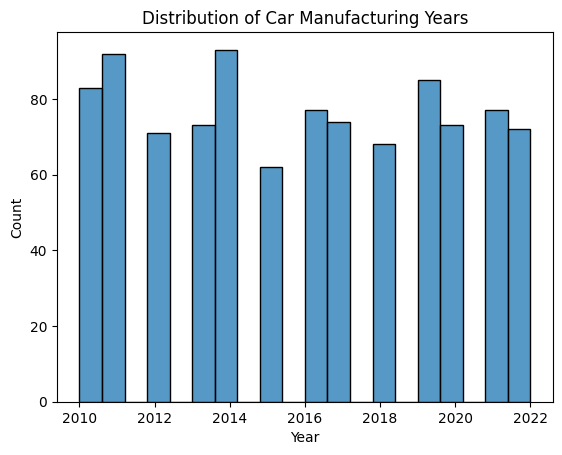

In [12]:
# histplot showing distribution of car years
sns.histplot(data=cars, x='Year', bins=20, kde=False)
plt.title('Distribution of Car Manufacturing Years')
plt.savefig(r"C:\Users\user\Desktop\Mine\docs\Car price analsis and prediction models\visualizations\distribution of car year-histplot.png")
plt.show()

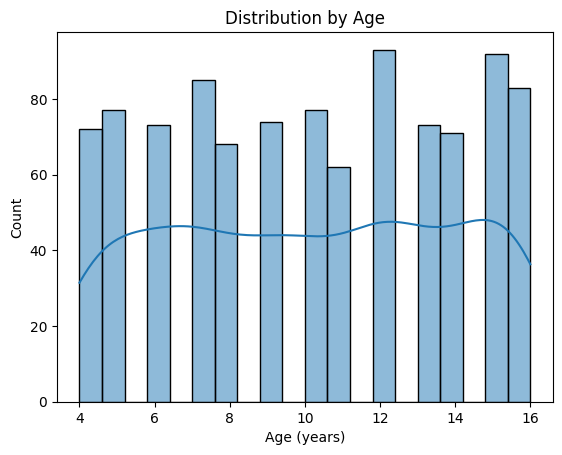

In [13]:
# Create an Age column
current_year = datetime.datetime.now().year
cars['Age'] = current_year - cars['Year']

# Age distribution
sns.histplot(data=cars, x='Age', bins=20, kde=True)
plt.title('Distribution by Age')
plt.xlabel('Age (years)')

plt.savefig(r"C:\Users\user\Desktop\Mine\docs\Car price analsis and prediction models\visualizations\distribution by age.png")
plt.show()

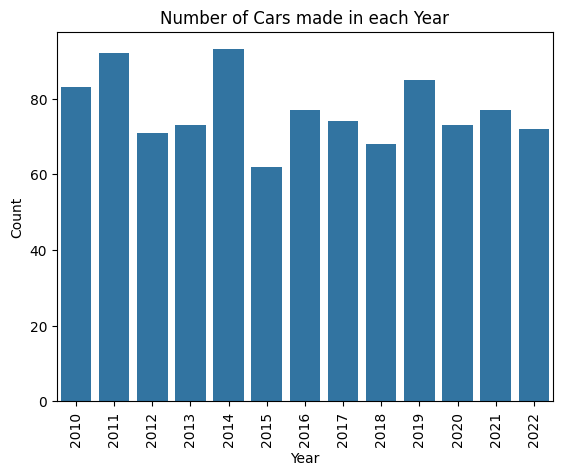

In [14]:
year_counts = cars['Year'].value_counts().sort_index()

sns.barplot(x=year_counts.index, y=year_counts.values)
plt.title('Number of Cars made in each Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.savefig(r"C:\Users\user\Desktop\Mine\docs\Car price analsis and prediction models\visualizations\number of cars in each year.png")
plt.show()

In [15]:
print(f"Oldest cars:   {cars['Year'].min()} ({current_year - cars['Year'].min()} years old)")
print(f"Newest cars:   {cars['Year'].max()}")
print(f"Average year: {cars['Year'].mean():.0f}")
print(f"Most cars were made on year {cars['Year'].mode()[0]}")

Oldest cars:   2010 (16 years old)
Newest cars:   2022
Average year: 2016
Most cars were made on year 2014


- Mileage distribution — identify high-mileage vs low-mileage segments

In [16]:
# Define mileage segments
def mileage_segment(mileage):
    if mileage < 30000:
        return 'Low (< 30k)'
    elif mileage < 70000:
        return 'Medium (30k–70k)'
    elif mileage < 120000:
        return 'High (70k–120k)'
    else:
        return 'Very High (> 120k)'

cars['Mileage_Segment'] = cars['Mileage'].apply(mileage_segment)

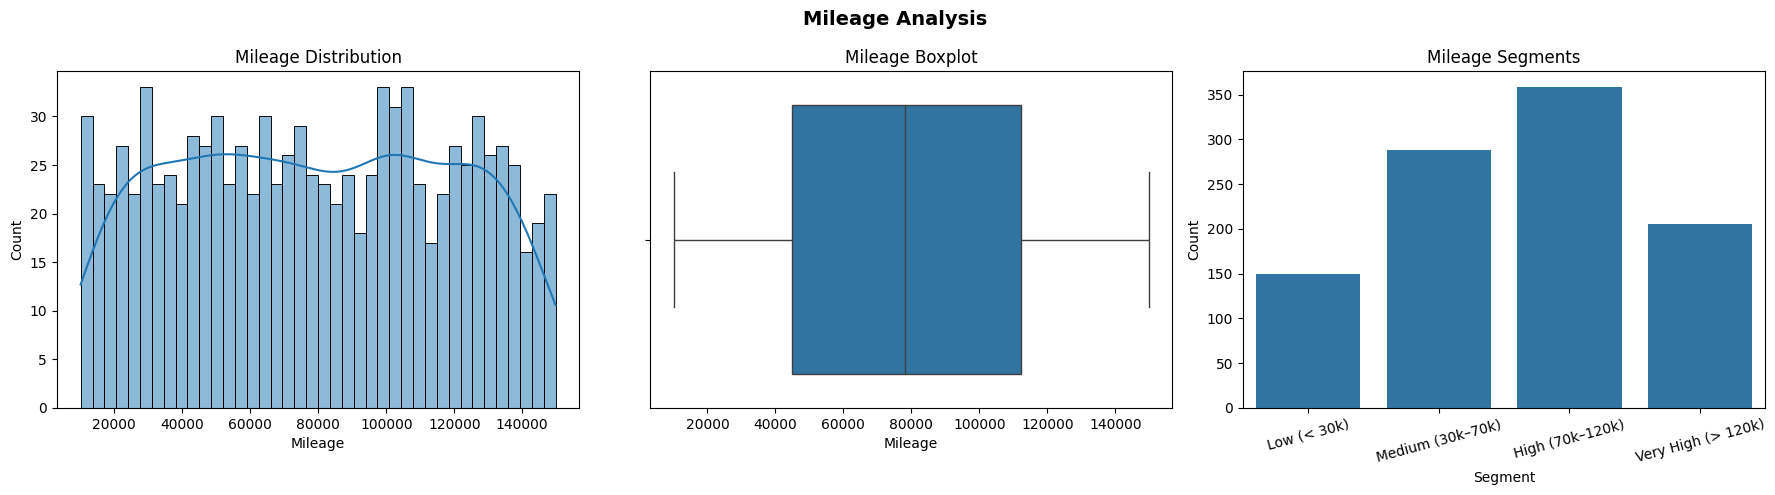

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histogram with KDE
sns.histplot(data=cars, x='Mileage', kde=True, bins=40, ax=axes[0])
axes[0].set_title('Mileage Distribution')
axes[0].set_xlabel('Mileage')

# 2. Boxplot — spot outliers
sns.boxplot(data=cars, x='Mileage', ax=axes[1])
axes[1].set_title('Mileage Boxplot')
axes[1].set_xlabel('Mileage')

# 3. Segment breakdown — bar chart
segment_order = ['Low (< 30k)', 'Medium (30k–70k)', 'High (70k–120k)', 'Very High (> 120k)']
segment_counts = cars['Mileage_Segment'].value_counts().reindex(segment_order)
sns.barplot(x=segment_counts.index, y=segment_counts.values, ax=axes[2])
axes[2].set_title('Mileage Segments')
axes[2].set_xlabel('Segment')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('Mileage Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig(r"C:\Users\user\Desktop\Mine\docs\Car price analsis and prediction models\visualizations\mileage analysis.png")
plt.show()

In [18]:
print(f"Lowest Mileage:   {cars['Mileage'].min():,}")
print(f"Highest Mileage:  {cars['Mileage'].max():,}")
print(f"Average Mileage:  {cars['Mileage'].mean():,.0f}")
print(f"Median Mileage:   {cars['Mileage'].median():,.0f}")
print(f"Skewness:         {cars['Mileage'].skew():.2f}")
print()
print("--- Segment Breakdown ---")
print(cars['Mileage_Segment'].value_counts().reindex(segment_order))

Lowest Mileage:   10,079
Highest Mileage:  149,794
Average Mileage:  78,797
Median Mileage:   78,056
Skewness:         0.01

--- Segment Breakdown ---
Mileage_Segment
Low (< 30k)           149
Medium (30k–70k)      288
High (70k–120k)       358
Very High (> 120k)    205
Name: count, dtype: int64


---

### Price analysis and visualization

- Price vs Mileage

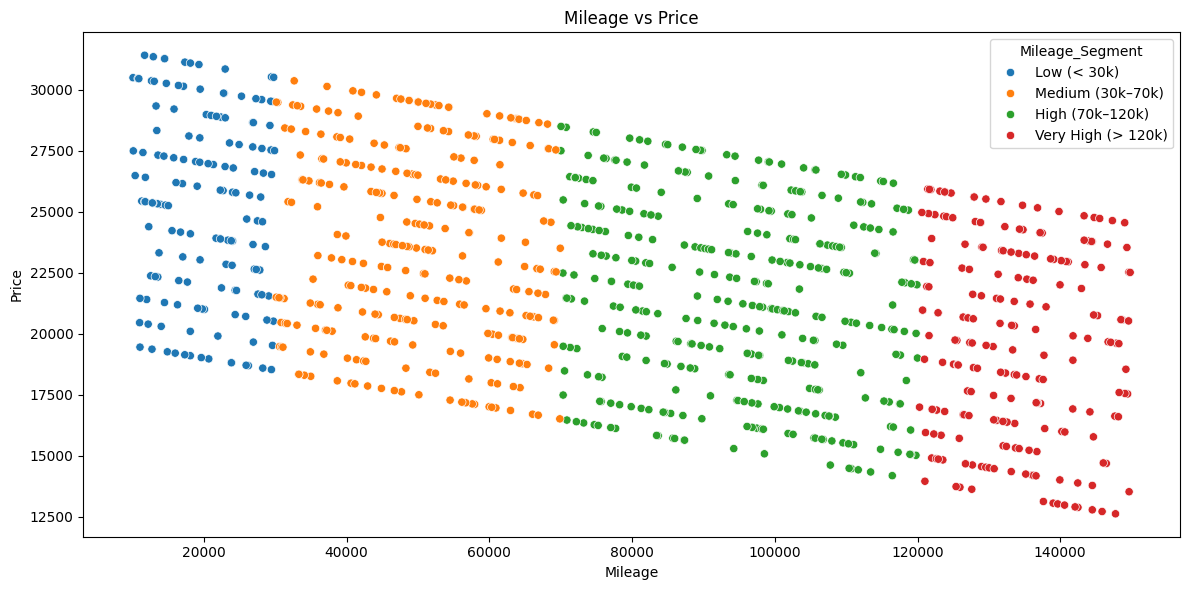

In [21]:
#check whether mileage correlates with price
plt.figure(figsize=(12,6))
sns.scatterplot(data=cars, x='Mileage', y='Price', hue='Mileage_Segment')
plt.title('Mileage vs Price')
plt.tight_layout()
plt.savefig(r"C:\Users\user\Desktop\Mine\docs\Car price analsis and prediction models\visualizations\Mileage vs price.png")
plt.show()

there is negative correlation between price and mileage

- Price vs Year — do newer cars command higher prices? (scatter/line)

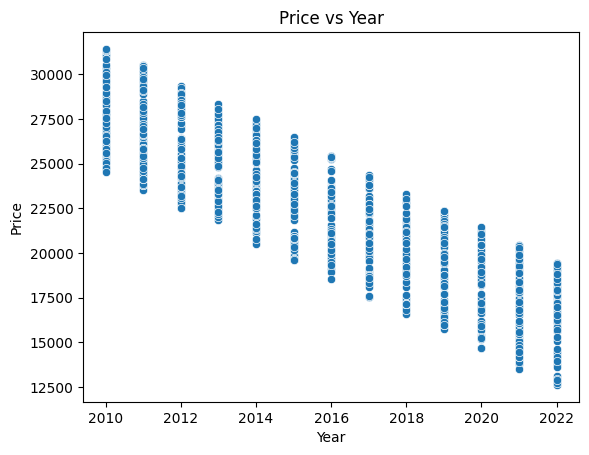

In [26]:
# scatterplot price vs year
sns.scatterplot(data=cars, x='Year', y='Price')
plt.title("Price vs Year")
plt.savefig(r"C:\Users\user\Desktop\Mine\docs\Car price analsis and prediction models\visualizations\scatterplot price vs year.png")
plt.show()

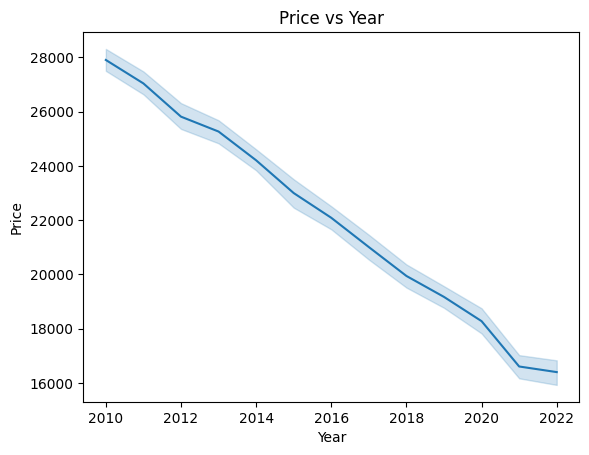

In [27]:
#line trend with years
sns.lineplot(data=cars, x='Year', y='Price')
plt.title("Price vs Year")
plt.savefig(r"C:\Users\user\Desktop\Mine\docs\Car price analsis and prediction models\visualizations\line trend with years.png")
plt.show()

there is a high negative correlation between price and year

- Price vs Condition — boxplot per condition category

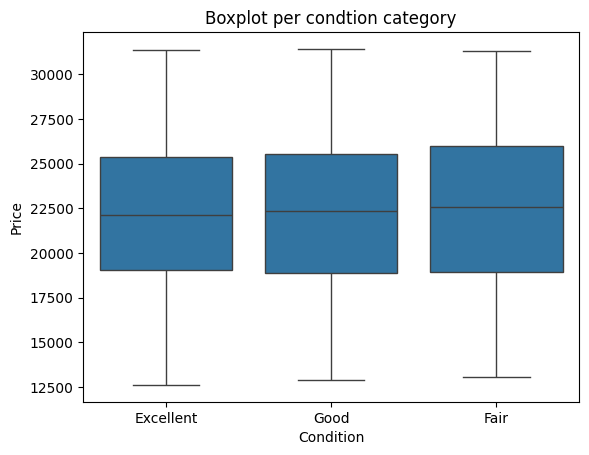

In [30]:
#boxplot per condition category
sns.boxplot(data=cars, x='Condition', y='Price')
plt.title("Boxplot per condtion category")
plt.savefig(r"C:\Users\user\Desktop\Mine\docs\Car price analsis and prediction models\visualizations\Boxplot per condition category.png")
plt.show()

- Price by Make — which brands hold value best? (grouped bar or boxplot)

In [38]:
price_by_make = cars.groupby("Make")["Price"].mean().reset_index()
print("\n Brands and their values: ")
price_by_make


 Brands and their values: 


,Make,Price
0,Chevrolet,21957.203589
1,Ford,22354.415578
2,Honda,22238.084171
3,Nissan,22587.502128
4,Toyota,21881.913415


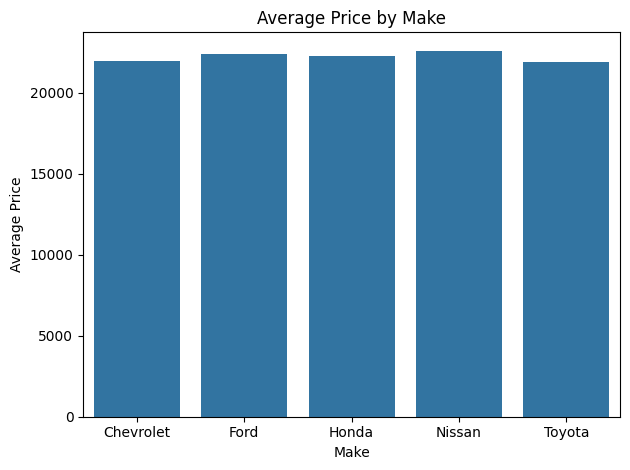

In [42]:
#price per make
sns.barplot(data=price_by_make, x='Make', y='Price')
plt.title('Average Price by Make')
plt.xlabel('Make')
plt.ylabel('Average Price')
plt.savefig(r"C:\Users\user\Desktop\Mine\docs\Car price analsis and prediction models\visualizations\Average price by make.png")
plt.tight_layout()
plt.show()

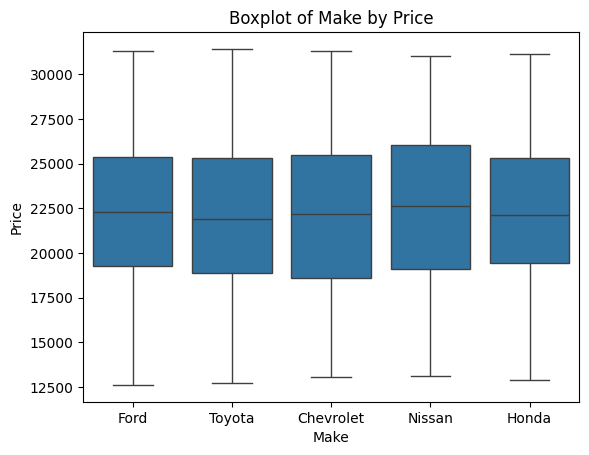

In [45]:
sns.boxplot(data=cars, x="Make", y="Price")
plt.title("Boxplot of Make by Price")
plt.savefig(r"C:\Users\user\Desktop\Mine\docs\Car price analsis and prediction models\visualizations\make by price.png")
plt.show()

- Price by Make + Condition — heatmap of average prices

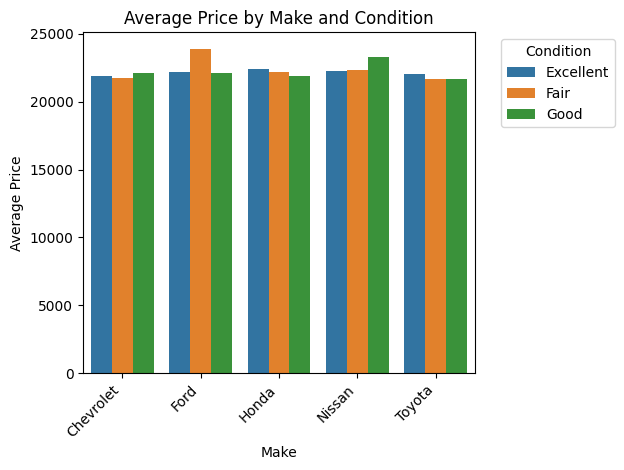

In [47]:
avg_price = cars.groupby(['Make', 'Condition'])['Price'].mean().reset_index()

sns.barplot(data=avg_price, x='Make', y='Price', hue='Condition')
plt.title('Average Price by Make and Condition')
plt.xlabel('Make')
plt.ylabel('Average Price')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(r"C:\Users\user\Desktop\Mine\docs\Car price analsis and prediction models\visualizations\price by make + condition.png")
plt.show()

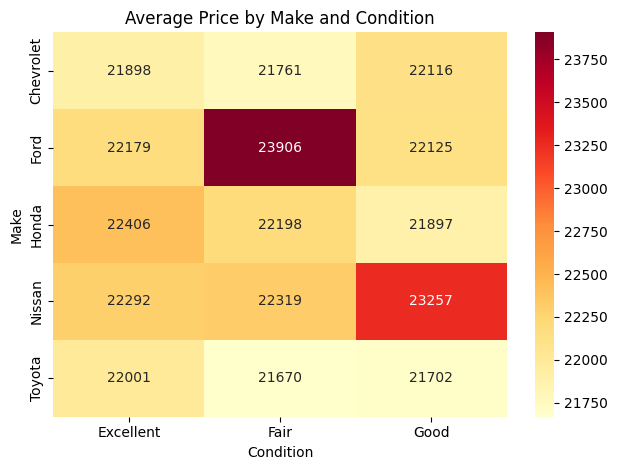

In [50]:
# Create a pivot table
pivot = cars.pivot_table(values='Price', index='Make', columns='Condition', aggfunc='mean')

sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Average Price by Make and Condition')
plt.xlabel('Condition')
plt.ylabel('Make')
plt.tight_layout()
plt.savefig(r"C:\Users\user\Desktop\Mine\docs\Car price analsis and prediction models\visualizations\heatmap-average price by make and condition.png")
plt.show()

---

### Depriciation and Value retention

- Price vs Age (current year − Year) — depreciation curve

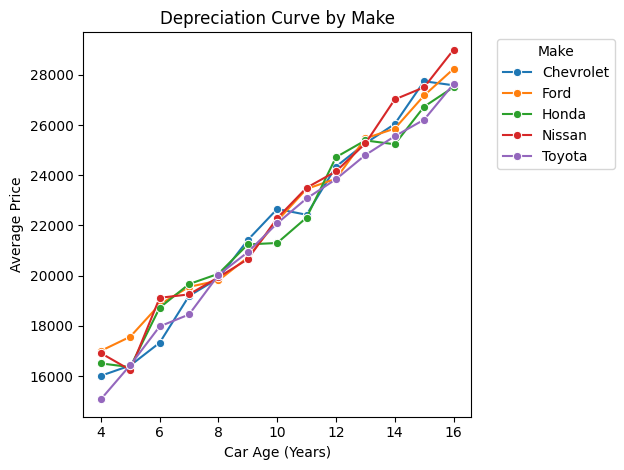

In [56]:
#depreciation curve
top_makes = cars['Make'].value_counts().index
df_top = cars[cars['Make'].isin(top_makes)]

avg_by_age_make = df_top.groupby(['Make', 'Age'])['Price'].mean().reset_index()

sns.lineplot(data=avg_by_age_make, x='Age', y='Price', hue='Make', marker='o')
plt.title('Depreciation Curve by Make')
plt.xlabel('Car Age (Years)')
plt.ylabel('Average Price')
plt.legend(title='Make', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig(r"C:\Users\user\Desktop\Mine\docs\Car price analsis and prediction models\visualizations\depreciation curve by make.png")
plt.tight_layout()
plt.show()

- Mileage vs Age — do older cars have proportionally more miles?

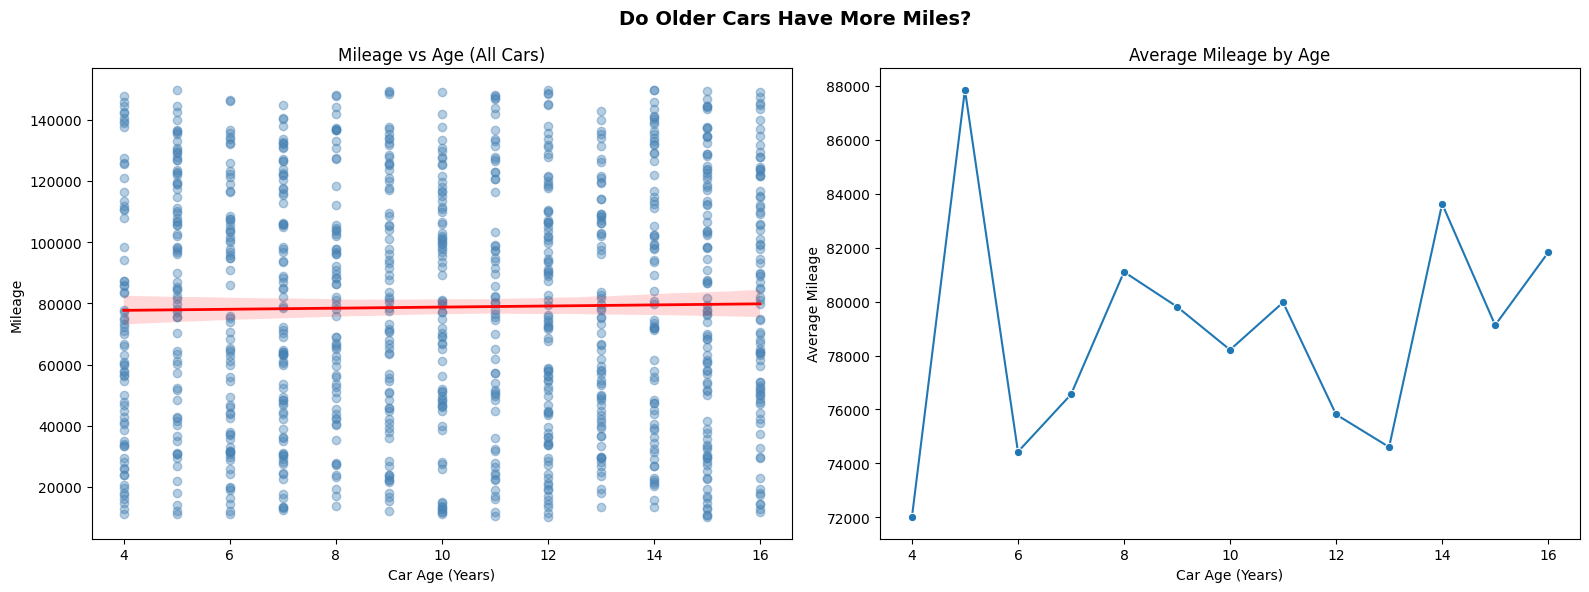

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter + trend
sns.regplot(data=cars, x='Age', y='Mileage',
    scatter_kws={'alpha': 0.4, 'color': 'steelblue'},
    line_kws={'color': 'red', 'linewidth': 2},
    ax=axes[0]
)
axes[0].set_title('Mileage vs Age (All Cars)')
axes[0].set_xlabel('Car Age (Years)')
axes[0].set_ylabel('Mileage')

# Average line
avg_mileage_by_age = cars.groupby('Age')['Mileage'].mean().reset_index()
sns.lineplot(data=avg_mileage_by_age, x='Age', y='Mileage', marker='o', ax=axes[1])
axes[1].set_title('Average Mileage by Age')
axes[1].set_xlabel('Car Age (Years)')
axes[1].set_ylabel('Average Mileage')

plt.suptitle('Do Older Cars Have More Miles?', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig(r"C:\Users\user\Desktop\Mine\docs\Car price analsis and prediction models\visualizations\Mileage vs age.png")
plt.show()

In [55]:
corr = cars['Age'].corr(cars['Mileage'])
print(f"Correlation between Age and Mileage: {corr:.2f}")

Correlation between Age and Mileage: 0.02


there is infact no correleation between the age and the mileage

---

###  Correlation Analysis and visualization

- Correlation matrix across Year, Mileage, Price

In [60]:
correlation_matrix = cars[['Year', 'Mileage', 'Price']].corr()
correlation_matrix

,Year,Mileage,Price
Year,1.000000,-0.01685,-0.883093
Mileage,-0.016850,1.00000,-0.454250
Price,-0.883093,-0.45425,1.000000


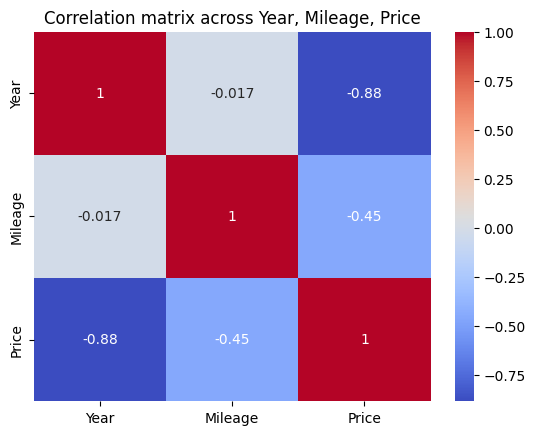

In [62]:
# heatmap for the correlation matrix 
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation matrix across Year, Mileage, Price")
plt.savefig(r"C:\Users\user\Desktop\Mine\docs\Car price analsis and prediction models\visualizations\Correlation across year,mileage and price.png")
plt.show()

- Check if mileage or age is a stronger price predictor

In [63]:
corr_mileage = cars['Mileage'].corr(cars['Price'])
corr_age     = cars['Age'].corr(cars['Price'])

print(f"Mileage vs Price correlation: {corr_mileage:.2f}")
print(f"Age vs Price correlation:     {corr_age:.2f}")
print()
print(f"Stronger predictor: {'Mileage' if abs(corr_mileage) > abs(corr_age) else 'Age'}")

Mileage vs Price correlation: -0.45
Age vs Price correlation:     0.88

Stronger predictor: Age


---

### Make & Model Analysis

- Most common Makes/Models — frequency counts

In [65]:
print("--- Top 3 Makes ---")
print(cars['Make'].value_counts().head(3))

print("\n--- Top 3 Models ---")
print(cars['Model'].value_counts().head(3))

--- Top 3 Makes ---
Make
Chevrolet    209
Toyota       205
Ford         199
Name: count, dtype: int64

--- Top 3 Models ---
Model
Altima       226
Camry        212
Silverado    192
Name: count, dtype: int64


C:\Users\user\AppData\Local\Temp\ipykernel_5488\2527925945.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=make_counts.values, y=make_counts.index, ax=axes[0], palette='viridis')
C:\Users\user\AppData\Local\Temp\ipykernel_5488\2527925945.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_counts.values, y=model_counts.index, ax=axes[1], palette='viridis')


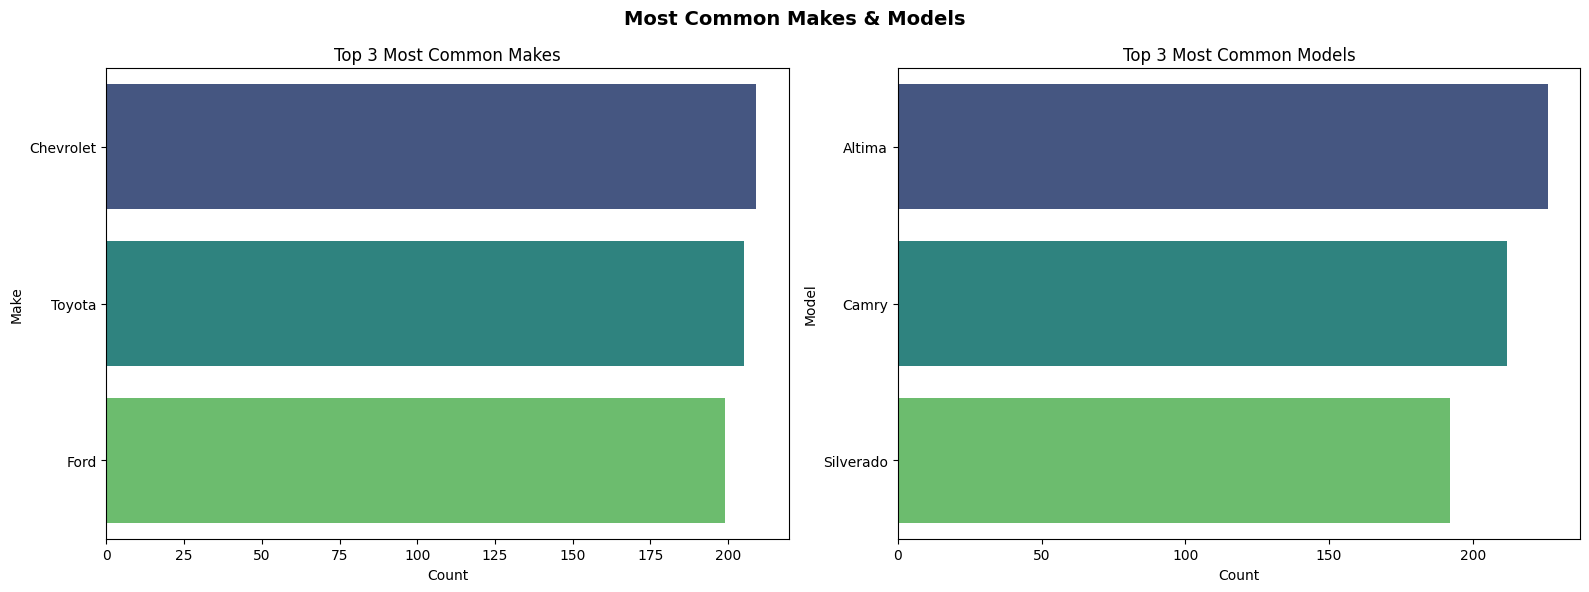

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 3 Makes
make_counts = cars['Make'].value_counts().head(3)
sns.barplot(x=make_counts.values, y=make_counts.index, ax=axes[0], palette='viridis')
axes[0].set_title('Top 3 Most Common Makes')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Make')

# Top 3 Models
model_counts = cars['Model'].value_counts().head(3)
sns.barplot(x=model_counts.values, y=model_counts.index, ax=axes[1], palette='viridis')
axes[1].set_title('Top 3 Most Common Models')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Model')

plt.suptitle('Most Common Makes & Models', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig(r"C:\Users\user\Desktop\Mine\docs\Car price analsis and prediction models\visualizations\Most common makes & models.png")

- Best value models — lowest price for a given condition/year bracket

In [70]:
cars['Year'].value_counts().sort_index()

Year
2010    83
2011    92
2012    71
2013    73
2014    93
2015    62
2016    77
2017    74
2018    68
2019    85
2020    73
2021    77
2022    72
Name: count, dtype: int64

In [75]:
# Create year brackets
cars['Year_Bracket'] = pd.cut(cars['Year'],bins=[2009, 2012, 2015, 2018, 2023],labels=['2010-2012', '2013-2015', '2016-2018', '2019-2023']
)

In [76]:
# Find cheapest model for each condition + year bracket combo
best_value = (cars.groupby(['Condition', 'Year_Bracket', 'Make', 'Model'])['Price']
                .mean()
                .reset_index()
                .sort_values(['Condition', 'Year_Bracket', 'Price'])
                .groupby(['Condition', 'Year_Bracket'])
                .first()
                .reset_index())

print(best_value[['Condition', 'Year_Bracket', 'Make', 'Model', 'Price']])

    Condition Year_Bracket       Make      Model         Price
0   Excellent    2010-2012      Honda  Silverado  24770.620000
1   Excellent    2013-2015      Honda      Civic  21955.512500
2   Excellent    2016-2018       Ford  Silverado  18944.787500
3   Excellent    2019-2023  Chevrolet     Altima  16016.281250
4        Fair    2010-2012      Honda      F-150  23838.825000
5        Fair    2013-2015       Ford  Silverado  22676.750000
6        Fair    2016-2018     Toyota      Camry  17649.750000
7        Fair    2019-2023     Toyota  Silverado  15010.800000
8        Good    2010-2012       Ford      F-150  23291.050000
9        Good    2013-2015       Ford  Silverado  20680.350000
10       Good    2016-2018     Toyota  Silverado  16592.750000
11       Good    2019-2023      Honda     Altima  14149.383333


C:\Users\user\AppData\Local\Temp\ipykernel_5488\3377208667.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  best_value = (cars.groupby(['Condition', 'Year_Bracket', 'Make', 'Model'])['Price']
C:\Users\user\AppData\Local\Temp\ipykernel_5488\3377208667.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['Condition', 'Year_Bracket'])


- Mileage by Make — are certain brands driven more?

In [78]:
avg_mileage_by_make = (cars.groupby('Make')['Mileage'].mean().sort_values(ascending=False).reset_index())

print(avg_mileage_by_make)

        Make       Mileage
0     Toyota  86655.556098
1      Honda  80163.994975
2  Chevrolet  79517.267943
3       Ford  74420.201005
4     Nissan  72612.627660


C:\Users\user\AppData\Local\Temp\ipykernel_5488\2493121290.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_mileage, x='Mileage', y='Make', palette='Blues_r')


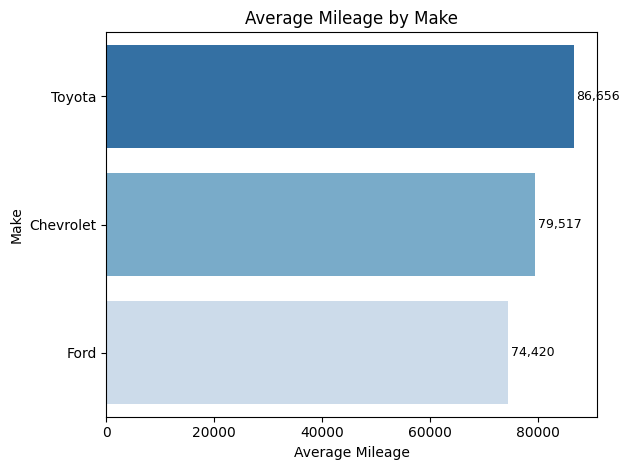

In [80]:
top_makes = cars['Make'].value_counts().head(3).index
df_top = cars[cars['Make'].isin(top_makes)]

avg_mileage = (df_top.groupby('Make')['Mileage'].mean().sort_values(ascending=False).reset_index())

sns.barplot(data=avg_mileage, x='Mileage', y='Make', palette='Blues_r')
plt.title('Average Mileage by Make')
plt.xlabel('Average Mileage')
plt.ylabel('Make')

# Add value labels to bars
for i, v in enumerate(avg_mileage['Mileage']):
    plt.text(v + 500, i, f'{v:,.0f}', va='center', fontsize=9)

plt.tight_layout()

plt.savefig(r"C:\Users\user\Desktop\Mine\docs\Car price analsis and prediction models\visualizations\Average Mileage by Make.png")
plt.show()

---

### Condition Analysis and visualization

- Condition vs Mileage — do high-mileage cars cluster in lower conditions?

In [81]:
avg_mileage_by_condition = (cars.groupby('Condition')['Mileage'].agg(['mean', 'median', 'count']).round(0).sort_values('mean', ascending=False))

print(avg_mileage_by_condition)

              mean   median  count
Condition                         
Good       79452.0  78188.0    292
Excellent  78867.0  78256.0    595
Fair       76739.0  76270.0    113


C:\Users\user\AppData\Local\Temp\ipykernel_5488\2992303303.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cars, x='Condition', y='Mileage',
C:\Users\user\AppData\Local\Temp\ipykernel_5488\2992303303.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_mileage, x='Condition', y='Mileage',
C:\Users\user\AppData\Local\Temp\ipykernel_5488\2992303303.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=cars, x='Condition', y='Mileage',


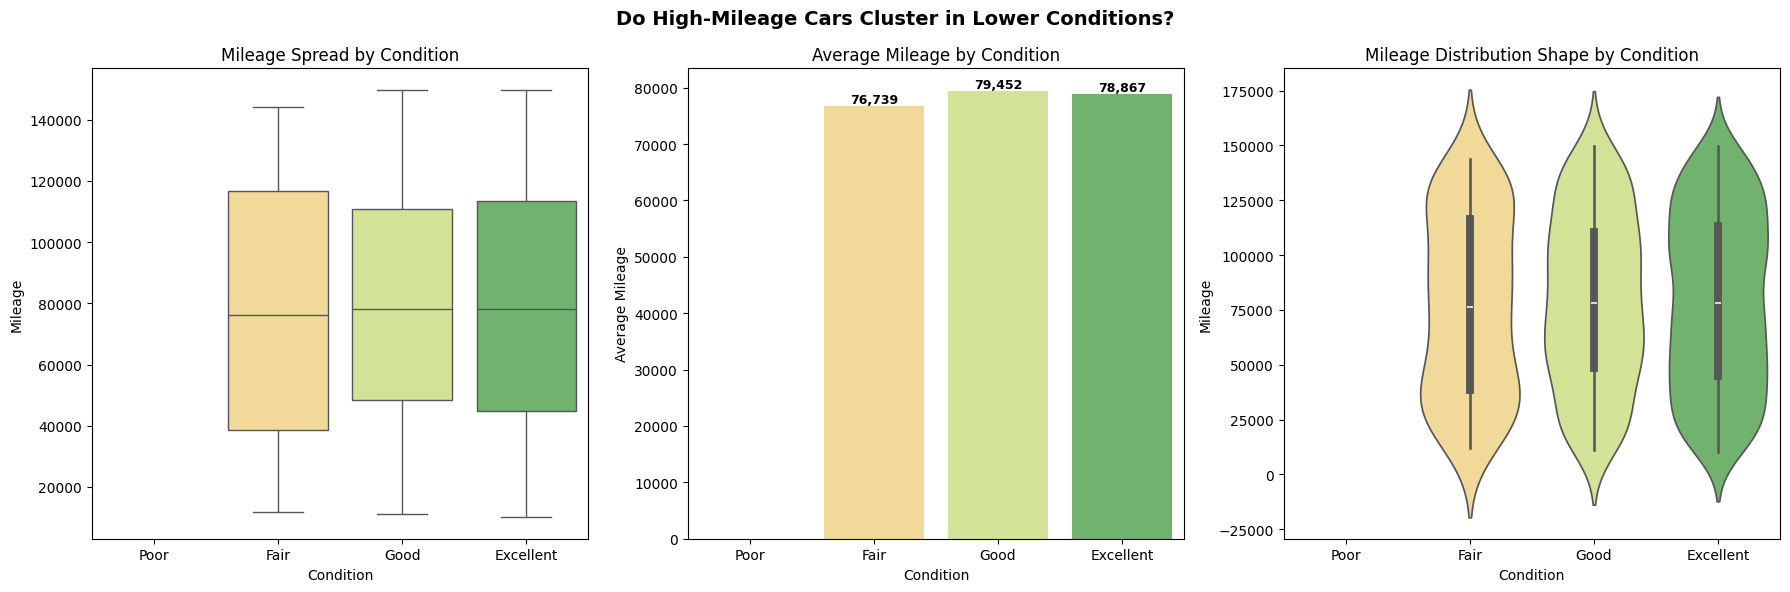

In [83]:
condition_order = ['Poor', 'Fair', 'Good', 'Excellent']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Boxplot
sns.boxplot(data=cars, x='Condition', y='Mileage', 
            order=condition_order, palette='RdYlGn', ax=axes[0])
axes[0].set_title('Mileage Spread by Condition')
axes[0].set_xlabel('Condition')
axes[0].set_ylabel('Mileage')

# 2. Bar chart — average mileage per condition
avg_mileage = (cars.groupby('Condition')['Mileage']
                 .mean()
                 .reindex(condition_order)
                 .reset_index())
sns.barplot(data=avg_mileage, x='Condition', y='Mileage', 
            order=condition_order, palette='RdYlGn', ax=axes[1])
axes[1].set_title('Average Mileage by Condition')
axes[1].set_xlabel('Condition')
axes[1].set_ylabel('Average Mileage')
for i, v in enumerate(avg_mileage['Mileage']):
    axes[1].text(i, v + 500, f'{v:,.0f}', ha='center', fontsize=9, fontweight='bold')

# 3. Violin plot — full distribution shape
sns.violinplot(data=cars, x='Condition', y='Mileage', 
               order=condition_order, palette='RdYlGn', ax=axes[2])
axes[2].set_title('Mileage Distribution Shape by Condition')
axes[2].set_xlabel('Condition')
axes[2].set_ylabel('Mileage')

plt.suptitle('Do High-Mileage Cars Cluster in Lower Conditions?', 
             fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig(r"C:\Users\user\Desktop\Mine\docs\Car price analsis and prediction models\visualizations\mileage vs conditions.png")
plt.show()

- Condition vs Year — are older cars in worse condition?

In [85]:
condition_order = ['Fair', 'Good', 'Excellent']

avg_year_by_condition = (cars.groupby('Condition')['Year'].agg(['mean', 'median', 'count']).round(0).reindex(condition_order))

print(avg_year_by_condition)

             mean  median  count
Condition                       
Fair       2016.0  2016.0    113
Good       2016.0  2016.0    292
Excellent  2016.0  2016.0    595


C:\Users\user\AppData\Local\Temp\ipykernel_5488\3555277558.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cars, x='Condition', y='Year',
C:\Users\user\AppData\Local\Temp\ipykernel_5488\3555277558.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_year, x='Condition', y='Year',
C:\Users\user\AppData\Local\Temp\ipykernel_5488\3555277558.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=cars, x='Condition', y='Year',


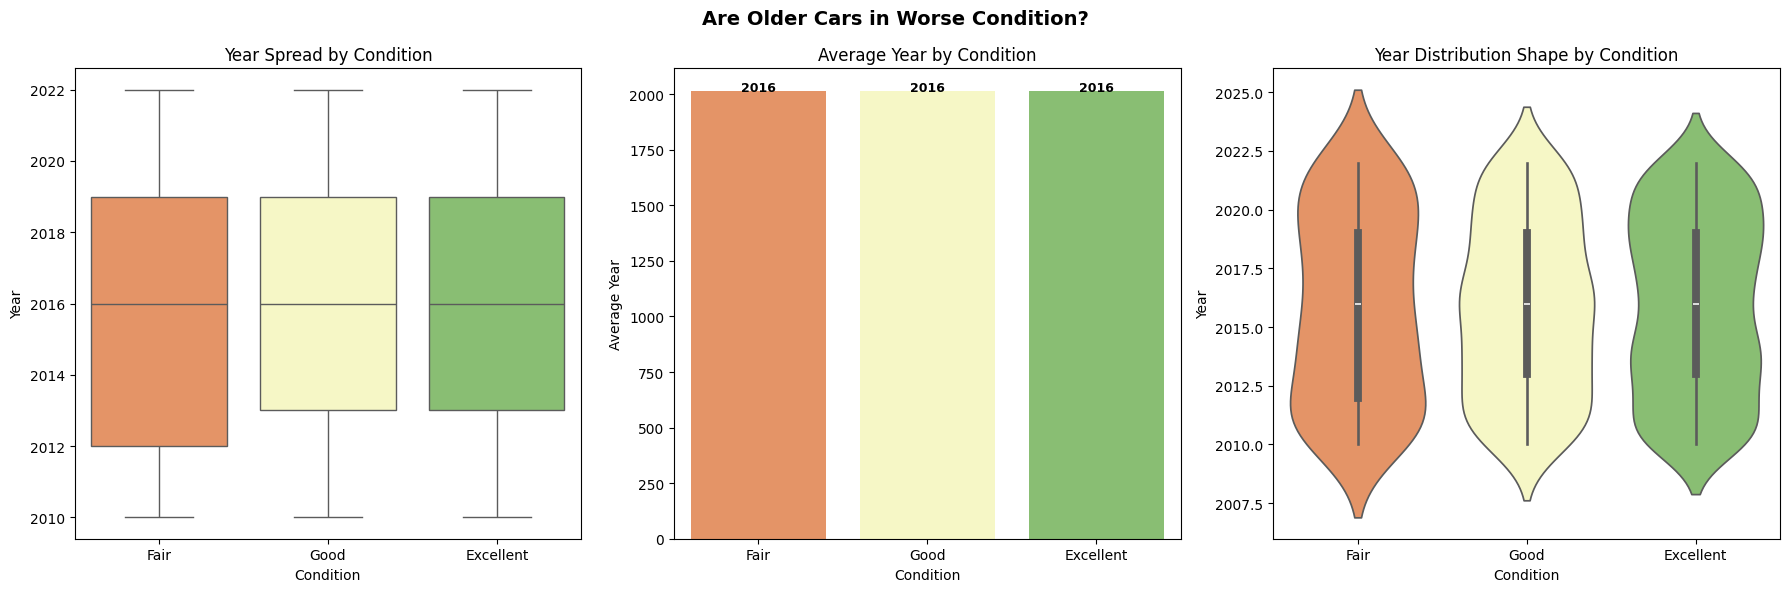

In [87]:

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Boxplot — year spread per condition
sns.boxplot(data=cars, x='Condition', y='Year',
            order=condition_order, palette='RdYlGn', ax=axes[0])
axes[0].set_title('Year Spread by Condition')
axes[0].set_xlabel('Condition')
axes[0].set_ylabel('Year')

# 2. Bar chart — average year per condition
avg_year = (cars.groupby('Condition')['Year']
              .mean()
              .reindex(condition_order)
              .reset_index())
sns.barplot(data=avg_year, x='Condition', y='Year',
            order=condition_order, palette='RdYlGn', ax=axes[1])
axes[1].set_title('Average Year by Condition')
axes[1].set_xlabel('Condition')
axes[1].set_ylabel('Average Year')
# Annotate bars
for i, v in enumerate(avg_year['Year']):
    axes[1].text(i, v + 0.1, f'{v:.0f}', ha='center', fontsize=9, fontweight='bold')

# 3. Violin plot — full distribution shape
sns.violinplot(data=cars, x='Condition', y='Year',
               order=condition_order, palette='RdYlGn', ax=axes[2])
axes[2].set_title('Year Distribution Shape by Condition')
axes[2].set_xlabel('Condition')
axes[2].set_ylabel('Year')

plt.suptitle('Are Older Cars in Worse Condition?', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig(r"C:\Users\user\Desktop\Mine\docs\Car price analsis and prediction models\visualizations\condition vs year.png")
plt.show()

- Average price per condition — clear pricing tiers?

In [88]:

price_by_condition = (cars.groupby('Condition')['Price'].agg(['mean', 'median', 'min', 'max', 'std']).round(0).reindex(condition_order))

price_by_condition.columns = ['Mean', 'Median', 'Min', 'Max', 'Std Dev']
print(price_by_condition)

              Mean   Median      Min      Max  Std Dev
Condition                                             
Fair       22358.0  22545.0  13050.0  31275.0   4481.0
Good       22223.0  22331.0  12896.0  31415.0   4259.0
Excellent  22151.0  22130.0  12613.0  31354.0   4199.0


C:\Users\user\AppData\Local\Temp\ipykernel_5488\3815069750.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_price, x='Condition', y='Price',
C:\Users\user\AppData\Local\Temp\ipykernel_5488\3815069750.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cars, x='Condition', y='Price',
C:\Users\user\AppData\Local\Temp\ipykernel_5488\3815069750.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=cars, x='Condition', y='Price',


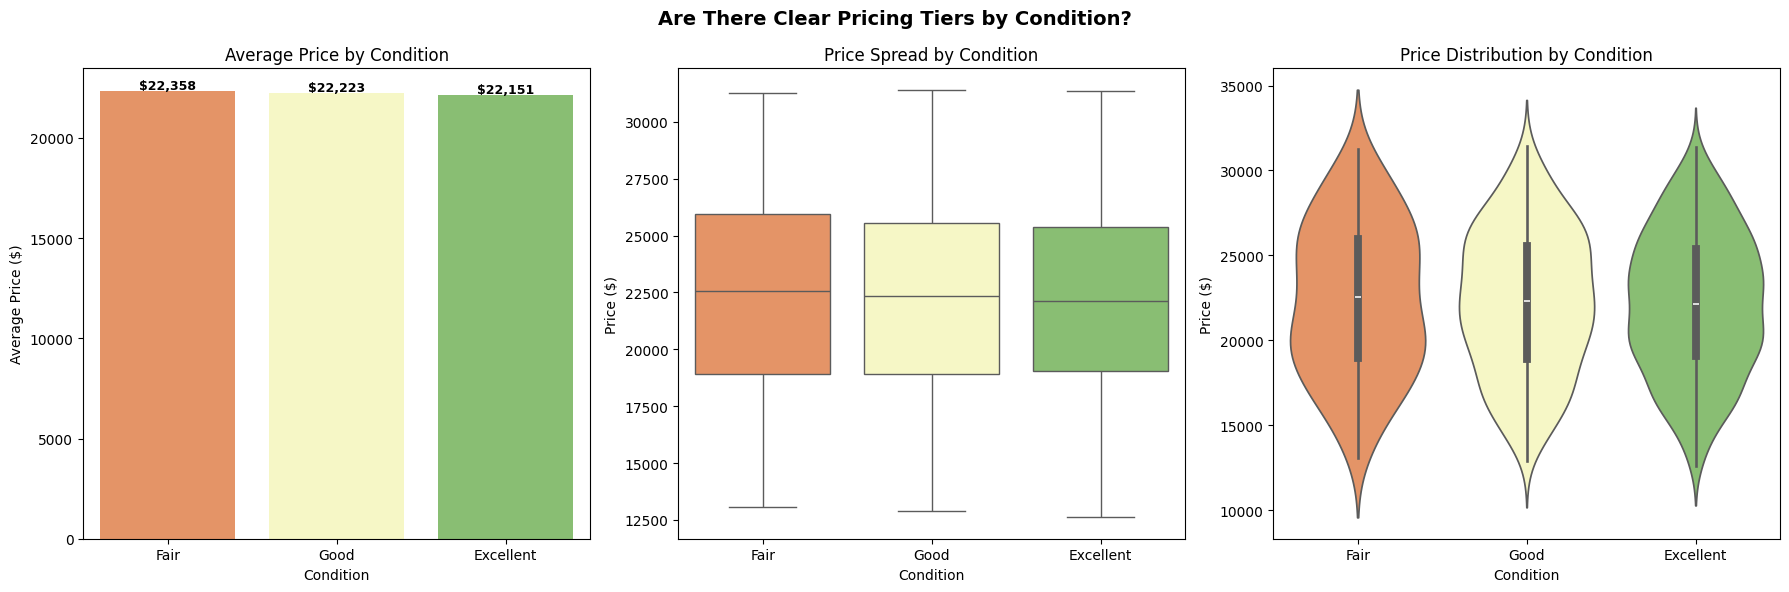

In [89]:

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Bar chart — average price
avg_price = (cars.groupby('Condition')['Price']
               .mean()
               .reindex(condition_order)
               .reset_index())
sns.barplot(data=avg_price, x='Condition', y='Price',
            order=condition_order, palette='RdYlGn', ax=axes[0])
axes[0].set_title('Average Price by Condition')
axes[0].set_xlabel('Condition')
axes[0].set_ylabel('Average Price ($)')
for i, v in enumerate(avg_price['Price']):
    axes[0].text(i, v + 100, f'${v:,.0f}', ha='center', fontsize=9, fontweight='bold')

# 2. Boxplot — full price spread
sns.boxplot(data=cars, x='Condition', y='Price',
            order=condition_order, palette='RdYlGn', ax=axes[1])
axes[1].set_title('Price Spread by Condition')
axes[1].set_xlabel('Condition')
axes[1].set_ylabel('Price ($)')

# 3. Violin — full distribution shape
sns.violinplot(data=cars, x='Condition', y='Price',
               order=condition_order, palette='RdYlGn', ax=axes[2])
axes[2].set_title('Price Distribution by Condition')
axes[2].set_xlabel('Condition')
axes[2].set_ylabel('Price ($)')

plt.suptitle('Are There Clear Pricing Tiers by Condition?', 
             fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig(r"C:\Users\user\Desktop\Mine\docs\Car price analsis and prediction models\visualizations\Average price per condition.png")
plt.show()

---